In [2]:
import nltk
nltk.download('treebank')
from nltk.corpus import treebank
import numpy as np

[nltk_data] Downloading package treebank to
[nltk_data]     /Users/larsheijnen/nltk_data...
[nltk_data]   Package treebank is already up-to-date!


In [34]:
# Print the raw first lines of the treebank data
print(treebank.raw()[:500])  # Print the first 500 characters for preview


( (S 
    (NP-SBJ 
      (NP (NNP Pierre) (NNP Vinken) )
      (, ,) 
      (ADJP 
        (NP (CD 61) (NNS years) )
        (JJ old) )
      (, ,) )
    (VP (MD will) 
      (VP (VB join) 
        (NP (DT the) (NN board) )
        (PP-CLR (IN as) 
          (NP (DT a) (JJ nonexecutive) (NN director) ))
        (NP-TMP (NNP Nov.) (CD 29) )))
    (. .) ))
( (S 
    (NP-SBJ (NNP Mr.) (NNP Vinken) )
    (VP (VBZ is) 
      (NP-PRD 
        (NP (NN chairman) )
        (PP (IN of) 
          (NP 
  


In [43]:
sentences = treebank.tagged_sents()
first_sentence = sentences[0]

# separate the words and the corresponding POS tags
words = []
pos_order = []
for word, pos in first_sentence:
    words.append(word)
    pos_order.append(pos)

# printing sentence and order of POS tags --> visualization of how the data looks like
print("Sentence:", " ".join(words))
print("POS Order:", " ".join(pos_order))


Sentence: Pierre Vinken , 61 years old , will join the board as a nonexecutive director Nov. 29 .
POS Order: NNP NNP , CD NNS JJ , MD VB DT NN IN DT JJ NN NNP CD .


In [45]:
sentences_text = [" ".join([word for word, _ in sentence]) for sentence in sentences]
sentence_lengths = [len(sentence) for sentence in sentences]

total_words = sum(sentence_lengths)
average_length = sum(len(sentence) for sentence in sentences) / len(sentences)
unique_pos_tags = set(pos_order)
unique_words = set(word for sentence in sentences for word, _ in sentence)
total_unique_words = len(unique_words)

all_pos_tags = []
for sentence in sentences:
    for _, pos in sentence:
        all_pos_tags.append(pos)

unique_pos_tags = set(all_pos_tags)


print(f"Total number of sentences: {len(sentences_text)}")
print(f"Total number of words: {total_words}")
print(f"Total number of unique words: {total_unique_words}")
print(f"Average sentence length: {average_length:.2f} words")
print(f"Number of unique POS tags: {len(unique_pos_tags)}")
print(f"Unique POS tags: {unique_pos_tags}")

Total number of sentences: 3914
Total number of words: 100676
Total number of unique words: 12408
Average sentence length: 25.72 words
Number of unique POS tags: 46
Unique POS tags: {'PRP$', ':', '-LRB-', 'PDT', 'MD', 'IN', 'SYM', 'NNPS', 'RBS', 'WRB', 'WP', '-NONE-', "''", 'VBG', 'VBN', '``', 'CC', 'EX', ',', 'NN', 'UH', '#', 'VB', 'WP$', 'FW', 'RB', 'POS', 'JJR', 'WDT', '$', 'LS', '-RRB-', 'NNS', 'PRP', 'RBR', 'VBP', 'DT', 'RP', 'JJ', 'TO', 'CD', 'NNP', 'JJS', 'VBD', '.', 'VBZ'}


In [33]:
def analyze_sentence(sentence_index):
    print("Sentence:", sentences_text[sentence_index])
    print("Sentence Length:", sentence_lengths[sentence_index])
    for idx, token in enumerate(sentences_text[sentence_index].split(), start=1):
        print(f"Token {idx}: {token}")
    print('\n')

analyze_sentence(80)
analyze_sentence(16)


Sentence: Then , in the guests ' honor , the speedway hauled out four drivers , crews and even the official Indianapolis 500 announcer for a 10-lap exhibition race .
Sentence Length: 29
Token 1: Then
Token 2: ,
Token 3: in
Token 4: the
Token 5: guests
Token 6: '
Token 7: honor
Token 8: ,
Token 9: the
Token 10: speedway
Token 11: hauled
Token 12: out
Token 13: four
Token 14: drivers
Token 15: ,
Token 16: crews
Token 17: and
Token 18: even
Token 19: the
Token 20: official
Token 21: Indianapolis
Token 22: 500
Token 23: announcer
Token 24: for
Token 25: a
Token 26: 10-lap
Token 27: exhibition
Token 28: race
Token 29: .


Sentence: Four of the five surviving workers have asbestos-related diseases , including three with recently diagnosed cancer .
Sentence Length: 17
Token 1: Four
Token 2: of
Token 3: the
Token 4: five
Token 5: surviving
Token 6: workers
Token 7: have
Token 8: asbestos-related
Token 9: diseases
Token 10: ,
Token 11: including
Token 12: three
Token 13: with
Token 14: recently

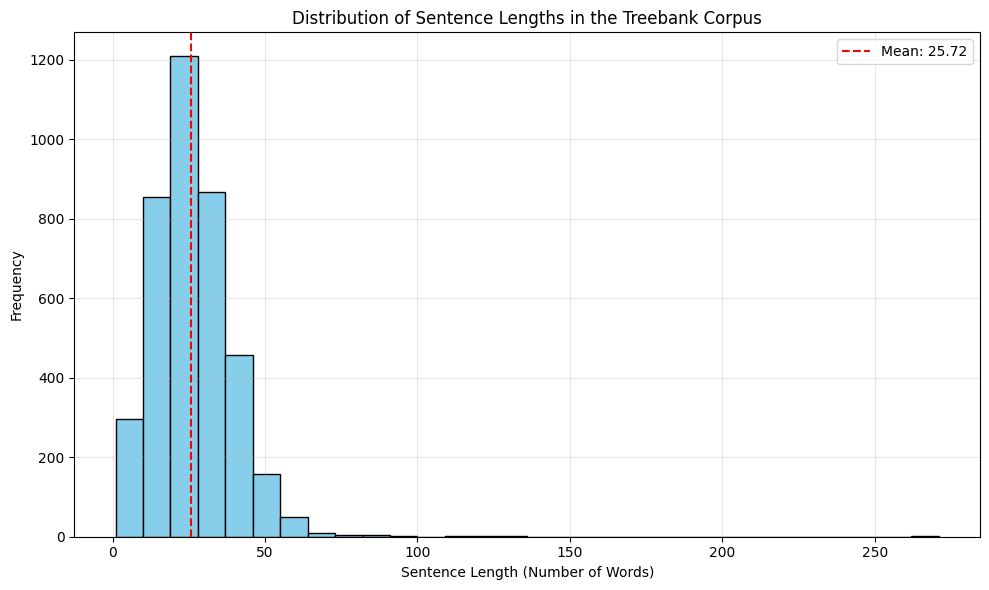

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(sentence_lengths, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Sentence Lengths in the Treebank Corpus')
plt.xlabel('Sentence Length (Number of Words)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.axvline(x=sum(sentence_lengths)/len(sentence_lengths), color='red', linestyle='--', label=f'Mean: {sum(sentence_lengths)/len(sentence_lengths):.2f}')
plt.legend()
plt.tight_layout()
plt.show()

Sentence Length Statistics:
Number of sentences: 3914
Mean length: 25.72 words
Median length: 25.00 words
Mode length: 22 words
Standard deviation: 12.87 words
Minimum length: 1 words
Maximum length: 271 words
25th percentile: 17.00 words
75th percentile: 33.00 words


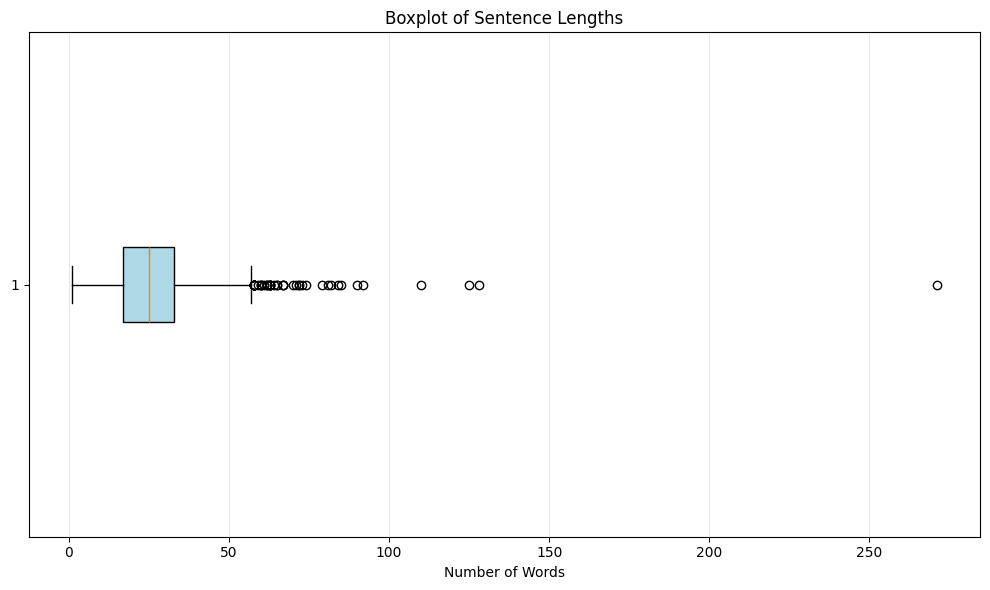

In [13]:
import numpy as np
from scipy import stats

# Calculate basic statistics
mean_length = np.mean(sentence_lengths)
median_length = np.median(sentence_lengths)
std_length = np.std(sentence_lengths)
min_length = min(sentence_lengths)
max_length = max(sentence_lengths)
mode_length = stats.mode(sentence_lengths, keepdims=False)[0]

# Print the statistics
print(f"Sentence Length Statistics:")
print(f"Number of sentences: {len(sentence_lengths)}")
print(f"Mean length: {mean_length:.2f} words")
print(f"Median length: {median_length:.2f} words")
print(f"Mode length: {mode_length} words")
print(f"Standard deviation: {std_length:.2f} words")
print(f"Minimum length: {min_length} words")
print(f"Maximum length: {max_length} words")
print(f"25th percentile: {np.percentile(sentence_lengths, 25):.2f} words")
print(f"75th percentile: {np.percentile(sentence_lengths, 75):.2f} words")

# Create a boxplot to visualize the distribution
plt.figure(figsize=(10, 6))
plt.boxplot(sentence_lengths, vert=False, patch_artist=True, 
            boxprops=dict(facecolor='lightblue'))
plt.title('Boxplot of Sentence Lengths')
plt.xlabel('Number of Words')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

def get_bert_embeddings(texts):
    embeddings = []
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    model.eval()
    
    # Process in batches to avoid memory issues
    batch_size = 32
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            inputs = tokenizer(batch_texts, padding=True, truncation=True, return_tensors='pt').to(device)
            outputs = model(**inputs)
            
            # Get token embedding (first token) for each sentence
            batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(batch_embeddings)
    
    return np.array(embeddings)

# Get BERT embeddings for sentences
print("Generating BERT embeddings for sentences...")
X_sentence_features = get_bert_embeddings(sentences_text)
print(f"Sentence BERT embeddings shape: {X_sentence_features.shape}")

/Users/larsheijnen/Internship/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating BERT embeddings for sentences...
Sentence BERT embeddings shape: (3914, 768)


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sentence_features, sentence_lengths, test_size=0.2, random_state=42
)

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on test set
predictions = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

# Print results
print(f"Linear Regression Results:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

Linear Regression Results:
Mean Squared Error: 26.9970
Mean Absolute Error: 3.9576
R² Score: 0.8149


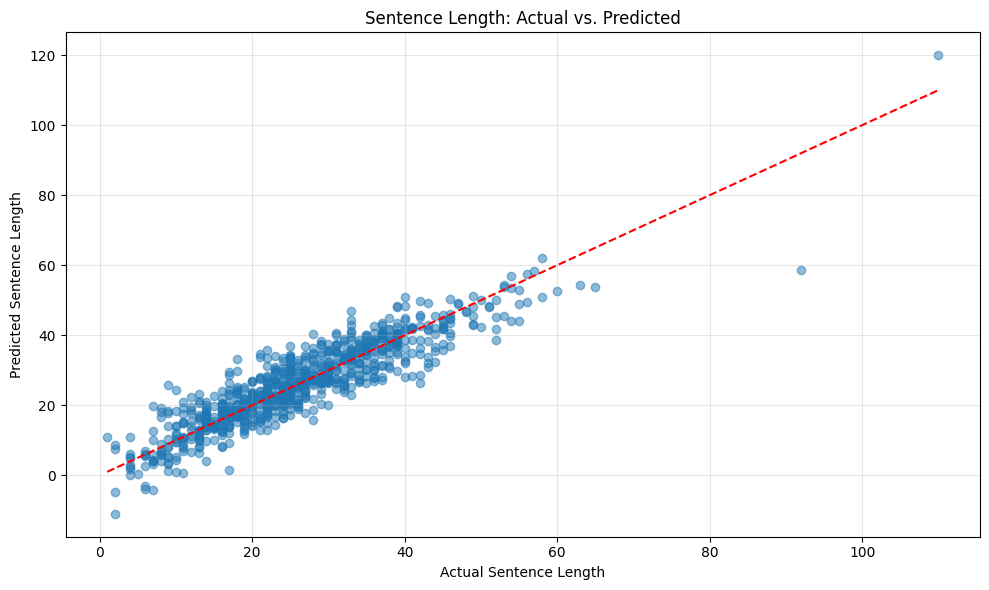

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel('Actual Sentence Length')
plt.ylabel('Predicted Sentence Length')
plt.title('Sentence Length: Actual vs. Predicted')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

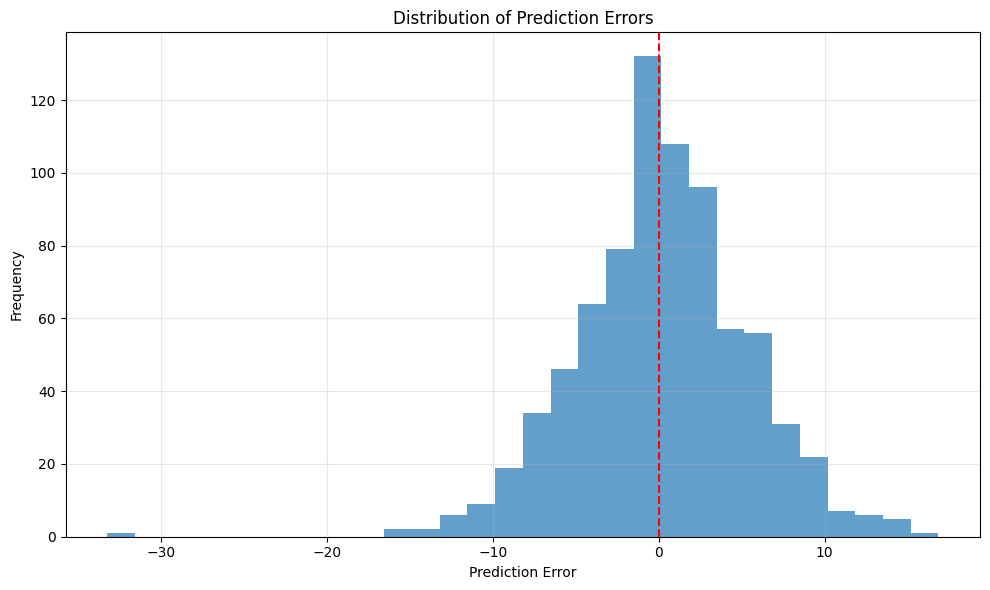

In [10]:
errors = predictions - y_test
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=30, alpha=0.7)
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.grid(alpha=0.3)
plt.axvline(x=0, color='r', linestyle='--')
plt.tight_layout()
plt.show()